In [1]:
! pip install pandas pyarrow fastparquet


In [2]:
import pandas as pd
file_paths = [
    "MovieData/0000.parquet",
    "MovieData/0001.parquet",
    "MovieData/0002.parquet",
    "MovieData/0003.parquet",
    "MovieData/0004.parquet",
    "MovieData/0005.parquet"
    
]



In [3]:
# Combine all files into a single DataFrame
dataframes = [pd.read_parquet(file) for file in file_paths]
moviedata = pd.concat(dataframes, ignore_index=True)

In [4]:
dataframes

[            videoid                                         contentUrl  \
 0          21179416  https://ak.picdn.net/shutterstock/videos/21179...   
 1           5629184  https://ak.picdn.net/shutterstock/videos/56291...   
 2        1063125190  https://ak.picdn.net/shutterstock/videos/10631...   
 3        1039695998  https://ak.picdn.net/shutterstock/videos/10396...   
 4           9607838  https://ak.picdn.net/shutterstock/videos/96078...   
 ...             ...                                                ...   
 1792495  1021499794  https://ak.picdn.net/shutterstock/videos/10214...   
 1792496  1033753421  https://ak.picdn.net/shutterstock/videos/10337...   
 1792497  1017392800  https://ak.picdn.net/shutterstock/videos/10173...   
 1792498  1032128717  https://ak.picdn.net/shutterstock/videos/10321...   
 1792499  1010553644  https://ak.picdn.net/shutterstock/videos/10105...   
 
             duration       page_dir  \
 0        PT00H00M11S  006001_006050   
 1        PT00H00M

In [5]:
moviedata

,videoid,contentUrl,duration,page_dir,name
0,21179416,https://ak.picdn.net/shutterstock/videos/21179...,PT00H00M11S,006001_006050,Aerial shot winter forest
1,5629184,https://ak.picdn.net/shutterstock/videos/56291...,PT00H00M29S,071501_071550,Senior couple looking through binoculars on sa...
2,1063125190,https://ak.picdn.net/shutterstock/videos/10631...,PT00H00M07S,133701_133750,A beautiful cookie with oranges lies on a gree...
3,1039695998,https://ak.picdn.net/shutterstock/videos/10396...,PT00H00M08S,011901_011950,Japanese highrise office skyscrapers tokyo square
4,9607838,https://ak.picdn.net/shutterstock/videos/96078...,PT00H00M32S,121551_121600,"Zrenjanin,serbia march 21 2015: fans watching ..."
...,...,...,...,...,...
10727602,34155514,https://ak.picdn.net/shutterstock/videos/34155...,PT00H00M25S,002601_002650,Tractor pulling land cultivating machine. aeri...
10727603,21838789,https://ak.picdn.net/shutterstock/videos/21838...,PT00H00M08S,030101_030150,Yellow green calcite mineral
10727604,1012616078,https://ak.picdn.net/shutterstock/videos/10126...,PT00H00M09S,060701_060750,Field with pink flowers in the foreground on a...
10727605,1054725683,https://ak.picdn.net/shutterstock/videos/10547...,PT00H00M10S,034851_034900,Morning sunrise over barley field. bad crop af...


In [6]:
# Get a quick overview
print(moviedata.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB
None


In [7]:
# Check a few rows
print(moviedata.head())



      videoid                                         contentUrl     duration  \
0    21179416  https://ak.picdn.net/shutterstock/videos/21179...  PT00H00M11S   
1     5629184  https://ak.picdn.net/shutterstock/videos/56291...  PT00H00M29S   
2  1063125190  https://ak.picdn.net/shutterstock/videos/10631...  PT00H00M07S   
3  1039695998  https://ak.picdn.net/shutterstock/videos/10396...  PT00H00M08S   
4     9607838  https://ak.picdn.net/shutterstock/videos/96078...  PT00H00M32S   

        page_dir                                               name  
0  006001_006050                          Aerial shot winter forest  
1  071501_071550  Senior couple looking through binoculars on sa...  
2  133701_133750  A beautiful cookie with oranges lies on a gree...  
3  011901_011950  Japanese highrise office skyscrapers tokyo square  
4  121551_121600  Zrenjanin,serbia march 21 2015: fans watching ...  


In [8]:
# Summary statistics for numerical columns
print(moviedata.describe())



            videoid
count  1.072761e+07
mean   5.798212e+08
std    5.044656e+08
min    1.300000e+01
25%    1.906638e+07
50%    1.010962e+09
75%    1.032311e+09
max    1.067376e+09


In [9]:
# Check for missing values
print(moviedata.isnull().sum())

videoid       0
contentUrl    0
duration      0
page_dir      0
name          0
dtype: int64


In [10]:
print(moviedata.columns)


Index(['videoid', 'contentUrl', 'duration', 'page_dir', 'name'], dtype='object')


In [11]:
# Optimize data types
moviedata['videoid'] = moviedata['videoid'].astype('int32')
moviedata['page_dir'] = moviedata['page_dir'].astype('category')
moviedata['duration'] = moviedata['duration'].astype('string')

# Verify memory usage after optimization
print(moviedata.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype   
---  ------      -----   
 0   videoid     int32   
 1   contentUrl  object  
 2   duration    string  
 3   page_dir    category
 4   name        object  
dtypes: category(1), int32(1), object(2), string(1)
memory usage: 307.1+ MB
None


In [12]:
# Unique values
print(f"Unique videos: {moviedata['videoid'].nunique()}")
print(f"Unique categories (page_dir): {moviedata['page_dir'].nunique()}")


Unique videos: 10727582
Unique categories (page_dir): 3590


In [13]:
# Convert ISO 8601 duration to seconds
import re

def duration_to_seconds(duration):
    match = re.match(r'PT(\d+H)?(\d+M)?(\d+S)?', duration)
    hours = int(match.group(1)[:-1]) if match.group(1) else 0
    minutes = int(match.group(2)[:-1]) if match.group(2) else 0
    seconds = int(match.group(3)[:-1]) if match.group(3) else 0
    return hours * 3600 + minutes * 60 + seconds

moviedata['duration_seconds'] = moviedata['duration'].apply(duration_to_seconds)

# Basic statistics
print(moviedata['duration_seconds'].describe())


count    1.072761e+07
mean     1.797064e+01
std      2.456413e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.500000e+01
75%      2.200000e+01
max      3.589100e+04
Name: duration_seconds, dtype: float64


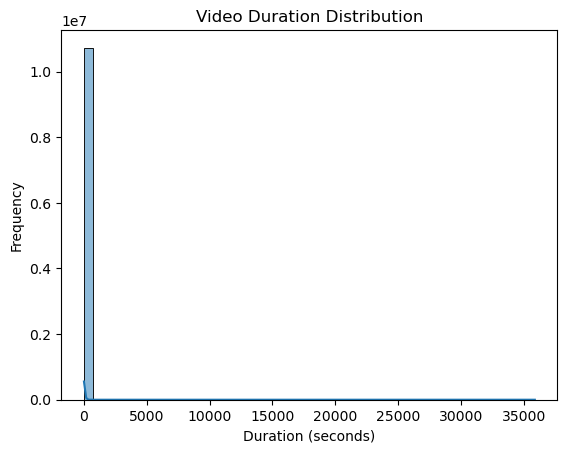

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(moviedata['duration_seconds'], bins=50, kde=True)
plt.title('Video Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()


In [15]:
# Count of extremely short and long videos
short_videos = moviedata[moviedata['duration_seconds'] == 0]
long_videos = moviedata[moviedata['duration_seconds'] > 300]

print(f"Number of 0-second videos: {len(short_videos)}")
print(f"Number of long videos (>5 min): {len(long_videos)}")


Number of 0-second videos: 270
Number of long videos (>5 min): 271


In [16]:
# Keep only reasonable durations (1s to 300s)
moviedata = moviedata[(moviedata['duration_seconds'] > 0) & (moviedata['duration_seconds'] <= 300)]


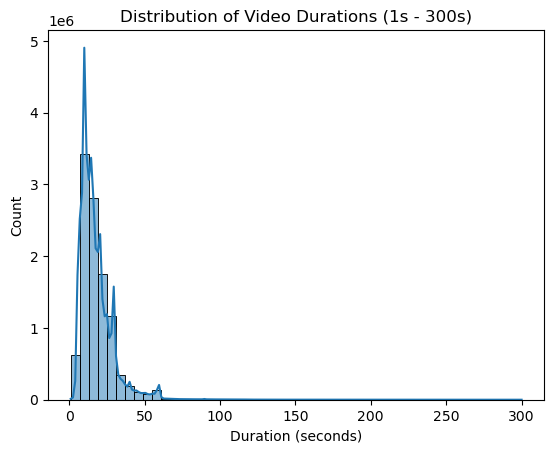

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(moviedata[moviedata['duration_seconds'] <= 300]['duration_seconds'], bins=50, kde=True)
plt.title("Distribution of Video Durations (1s - 300s)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()


In [18]:
long_videos = moviedata[moviedata['duration_seconds'] > 300]
print(long_videos[['videoid', 'duration_seconds', 'name']].head(10))


Empty DataFrame
Columns: [videoid, duration_seconds, name]
Index: []


page_dir
099101_099150    19.140919
040401_040450    18.785806
185601_185650    18.774830
129301_129350    18.773705
094751_094800    18.729557
048501_048550    18.705961
082301_082350    18.704847
094951_095000    18.690372
105551_105600    18.682993
017901_017950    18.654834
Name: duration_seconds, dtype: float64


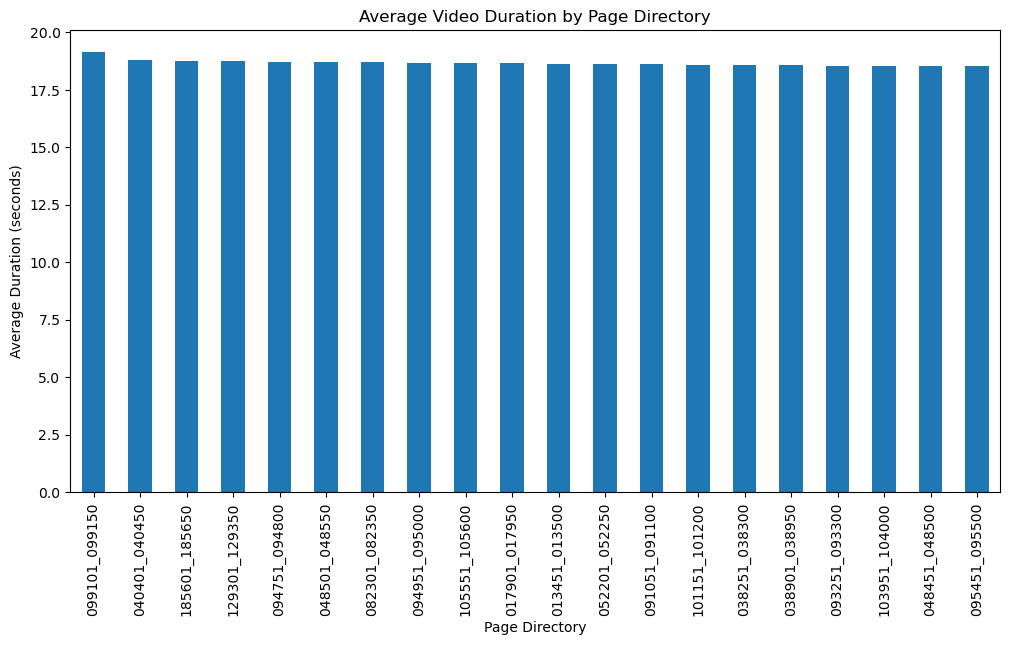

In [19]:
duration_by_category = moviedata.groupby('page_dir')['duration_seconds'].mean().sort_values(ascending=False)
print(duration_by_category.head(10))

# Bar plot of average duration per category
duration_by_category.head(20).plot(kind='bar', figsize=(12, 6), title='Average Video Duration by Page Directory')
plt.xlabel("Page Directory")
plt.ylabel("Average Duration (seconds)")
plt.show()


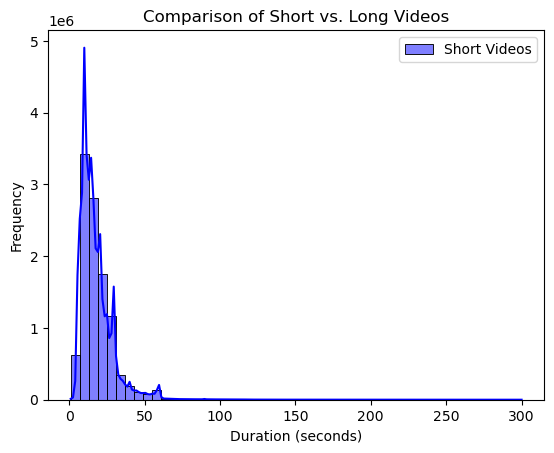

In [20]:
import seaborn as sns

# Plot short vs. long video distributions
sns.histplot(moviedata[moviedata['duration_seconds'] <= 300]['duration_seconds'], bins=50, kde=True, label="Short Videos", color="blue")
sns.histplot(long_videos['duration_seconds'], bins=50, kde=True, label="Long Videos", color="red")
plt.legend()
plt.title("Comparison of Short vs. Long Videos")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()


In [21]:
longest_videos = long_videos.nlargest(5, 'duration_seconds')
print(longest_videos[['videoid', 'duration_seconds', 'name']])


Empty DataFrame
Columns: [videoid, duration_seconds, name]
Index: []


In [24]:
# from collections import Counter
# import nltk
# from nltk.corpus import stopwords

# nltk.download('stopwords')
# stop_words = set(stopwords.words('english'))

# # Tokenize and clean titles
# long_keywords = long_videos['name'].str.split().explode()
# long_keywords = long_keywords.str.lower().str.replace(r'[^a-z]', '', regex=True)
# long_keywords = long_keywords[~long_keywords.isin(stop_words)]

# # Count common words
# common_long_keywords = Counter(long_keywords).most_common(20)
# print(common_long_keywords)

# # Bar plot of common words in long videos
# import pandas as pd
# pd.DataFrame(common_long_keywords, columns=['Keyword', 'Frequency']).set_index('Keyword').plot(kind='bar', figsize=(12, 6))
# plt.title("Top 20 Keywords in Long Video Titles")
# plt.show()


page_dir
000001_000050    4839
061101_061150    4703
032001_032050    4660
144051_144100    4654
071601_071650    4652
082801_082850    4622
189751_189800    4614
127351_127400    4607
138951_139000    4603
190651_190700    4602
Name: count, dtype: int64


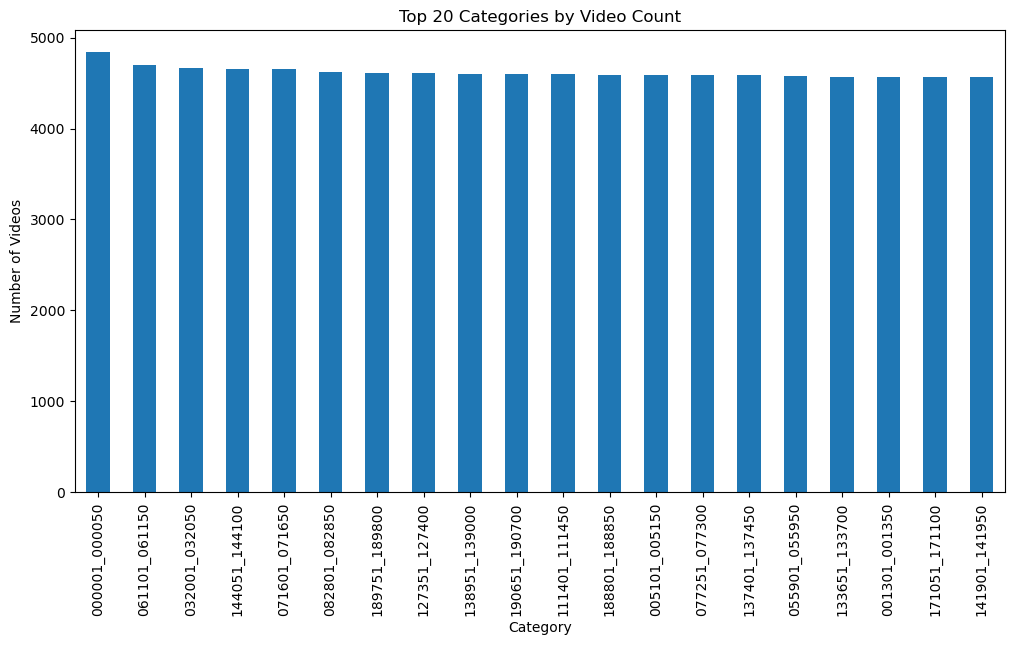

In [25]:
# Videos per category
category_counts = moviedata['page_dir'].value_counts()
print(category_counts.head(10))  # Top 10 categories

# Visualization
category_counts.head(20).plot(kind='bar', figsize=(12, 6))
plt.title("Top 20 Categories by Video Count")
plt.xlabel("Category")
plt.ylabel("Number of Videos")
plt.show()


In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Tokenize and clean titles
keywords = moviedata['name'].str.split().explode()
keywords = keywords.str.lower().str.replace(r'[^a-z]', '', regex=True)
keywords = keywords[~keywords.isin(stop_words)]

# Count and visualize
common_keywords = Counter(keywords).most_common(20)
print(common_keywords)

# Bar chart
import pandas as pd
pd.DataFrame(common_keywords, columns=['Keyword', 'Frequency']).set_index('Keyword').plot(kind='bar', figsize=(12, 6))
plt.title("Top 20 Keywords in Video Titles")
plt.show()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\obith\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


C:\Users\obith\AppData\Local\Temp\ipykernel_8116\2061713438.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  moviedata['domain'] = moviedata['contentUrl'].str.extract(r'https?://([^/]+)')


domain
ak.picdn.net    10727066
Name: count, dtype: int64


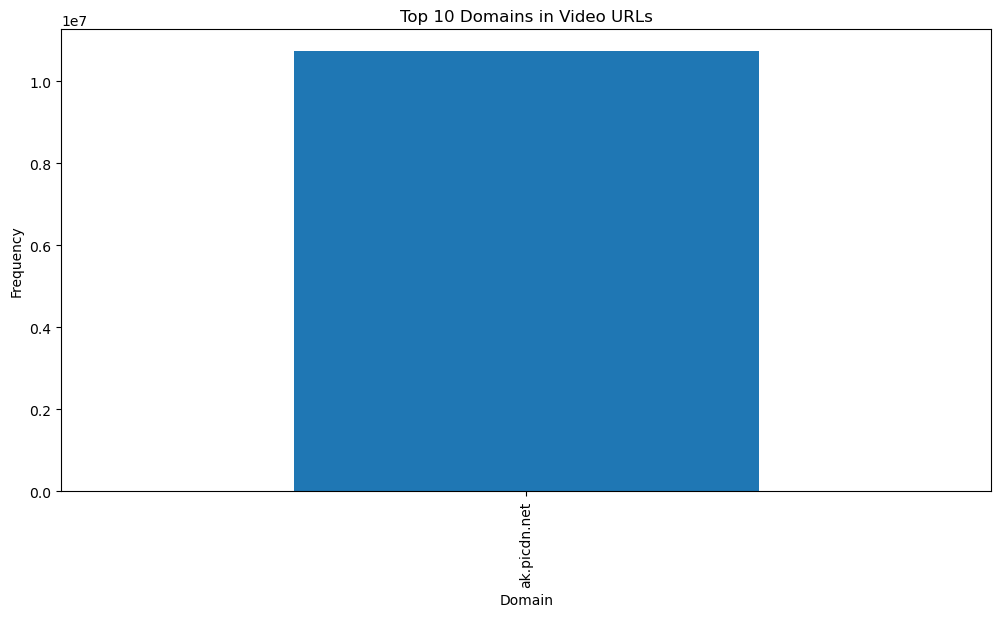

In [26]:
# Check for unique domains
moviedata['domain'] = moviedata['contentUrl'].str.extract(r'https?://([^/]+)')
domain_counts = moviedata['domain'].value_counts()

# Top domains
print(domain_counts.head(10))

# Plot domain distribution
domain_counts.head(10).plot(kind='bar', figsize=(12, 6))
plt.title("Top 10 Domains in Video URLs")
plt.xlabel("Domain")
plt.ylabel("Frequency")
plt.show()


In [28]:
! pip install imageio[ffmpeg] ffmpeg-python


  Obtaining dependency information for ffmpeg-python from https://files.pythonhosted.org/packages/d7/0c/56be52741f75bad4dc6555991fabd2e07b432d333da82c11ad701123888a/ffmpeg_python-0.2.0-py3-none-any.whl.metadata
  Obtaining dependency information for imageio-ffmpeg from https://files.pythonhosted.org/packages/2c/c6/fa760e12a2483469e2bf5058c5faff664acf66cadb4df2ad6205b016a73d/imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.2 MB 991.0 kB/s eta 0:00:32
   ---------------------------------------- 0.1/31.2 MB 1.1 MB/s eta 0:00:29
   ---------------------------------------- 0.2/31.2 MB 1.1 MB/s eta 0:00:28
   ---------------------------------------- 0.3/31.2 MB 1.6 MB/s eta 0:00:20
    --------------------------------------- 0.6/31.2 MB 2.6 MB/s eta 0:00:12
    --------------------------------------- 0.7/31.2 MB 2.7 MB/s eta 0:00:12
   - -------------------------------

In [30]:
! pip install moviepy


  Obtaining dependency information for moviepy from https://files.pythonhosted.org/packages/61/ee/ef46fdfbdc7e1316da60142ffc1867e6e12a22341636dce62856bb325272/moviepy-2.1.2-py3-none-any.whl.metadata
  Obtaining dependency information for numpy>=1.25.0 from https://files.pythonhosted.org/packages/66/a3/4139296b481ae7304a43581046b8f0a20da6a0dfe0ee47a044cade796603/numpy-2.2.2-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     -------------------- ------------------- 30.7/60.8 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 60.8/60.8 kB 1.1 MB/s eta 0:00:00
  Obtaining dependency information for proglog<=1.0.0 from https://files.pythonhosted.org/packages/8b/f5/cab5cf6a540c31f5099043de0ae43990fd9cf66f75ecb5e9f254a4e4d4ee/proglog-0.1.10-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/126.7 kB ? eta -:--:--
   ---------------------------------------- 126.7/126.7 kB 7.3 MB/s eta 0:00:00

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 2.2.2 which is incompatible.
scipy 1.11.1 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.2.2 which is incompatible.
tensorboard 2.15.1 requires protobuf<4.24,>=3.19.6, but you have protobuf 5.29.0 which is incompatible.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.2.2 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.0 which is incompatible.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have nu

In [31]:
import os
import pandas as pd
import numpy as np
import requests
import cv2
import ffmpeg
from tqdm import tqdm
from moviepy.editor import VideoFileClip
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\obith\anaconda31\Lib\site-packages\numpy\_typing\_scalars.py:12: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  _BoolLike_co: TypeAlias = bool | np.bool


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\obith\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\obith\AppData\Local\Temp\ipykernel_8116\984445254.py", line 8, in <module>
    from moviepy.editor import VideoFileClip
  File "c:\Users\obith\anaconda31\Lib\site-packages\moviepy\__init__.py", line 4, in <module>
    from moviepy.audio import fx as afx
  File "c:\Users\obith\anaconda31\Lib\site-packages\moviepy\audio\fx\__init__.py", line 5, in <module>
    from moviepy.audio.fx.AudioDelay import AudioDelay
  File "c:\Users\obith\anaconda31\Lib\site-packages\moviepy\audio\fx\AudioDelay.py", line 5, in <module>
    from moviepy.audio.AudioClip import CompositeAudioClip
  File "c:\Users\obith\anaconda31\Lib\site-packages\moviepy\audio\AudioClip.py", line 13, in <module>
    from moviepy.audio.io.ffmpeg_audiowriter import ffmpeg_audiowrite
  File "c:\Users\o

In [32]:
video_save_dir = "videos"
os.makedirs(video_save_dir, exist_ok=True)

def download_video(video_url, save_path):
    try:
        response = requests.get(video_url, stream=True, timeout=10)
        if response.status_code == 200:
            with open(save_path, "wb") as file:
                for chunk in response.iter_content(chunk_size=1024):
                    file.write(chunk)
            return True
    except Exception as e:
        print(f"Failed to download {video_url}: {e}")
    return False

In [33]:
# Download first 10 videos for testing
for index, row in tqdm(moviedata.head(10).iterrows(), total=10):
    video_url = row['contentUrl']
    video_id = row['videoid']
    save_path = os.path.join(video_save_dir, f"{video_id}.mp4")
    
    if not os.path.exists(save_path):  # Avoid re-downloading
        success = download_video(video_url, save_path)
        print(f"Downloaded: {save_path}" if success else f"Failed: {video_url}")

 10%|█         | 1/10 [00:00<00:08,  1.07it/s]

Downloaded: videos\21179416.mp4


 20%|██        | 2/10 [00:02<00:10,  1.28s/it]

Downloaded: videos\5629184.mp4


 30%|███       | 3/10 [00:03<00:06,  1.05it/s]

...

Downloaded: videos\19107358.mp4


 90%|█████████ | 9/10 [00:08<00:00,  1.04it/s]

Downloaded: videos\1036840850.mp4


100%|██████████| 10/10 [00:08<00:00,  1.17it/s]

Downloaded: videos\13347398.mp4
